In [ ]:
!pip install easyocr
!pip install ultralytics
!apt install -y tesseract-ocr
!pip install pytesseract


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 67.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 38.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.2/663.2 kB 4.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa

In [ ]:
#  import shutil

#  # Specify the path of the folder to be removed
# folder_path = '/content/predict_images3'

#   # Use shutil.rmtree to remove the folder and its contents
# shutil.rmtree(folder_path)


In [ ]:
from ultralytics import YOLO
import cv2
import easyocr
import os
import shutil
import tensorflow as tf
import random
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, atan, degrees
import shutil
import pytesseract


In [ ]:
# Function to find the longest line in the image
def find_longest_line(plate_img_gr):
    kernel_size = 7
    blur_gray = cv2.GaussianBlur(plate_img_gr, (kernel_size, kernel_size), 0)

    low_threshold = 150
    high_threshold = 220

    edges = cv2.Canny(blur_gray, low_threshold, high_threshold)

    rho = 1  # distance resolution in pixels of the Hough grid
    theta = np.pi / 180  # angular resolution in radians of the Hough grid
    threshold = 20  # minimum number of votes (intersections in Hough grid cell)
    min_line_length = 50  # minimum number of pixels making up a line
    max_line_gap = 5  # maximum gap in pixels between connectable line segments
    line_image = np.copy(plate_img_gr) * 0  # creating a blank to draw lines on

    # Run Hough on edge detected image
    # Output "lines" is an array containing endpoints of detected line segments
    lines = cv2.HoughLinesP(edges, rho, theta, threshold, np.array([]),
                            min_line_length, max_line_gap)

    lls = []
    for indx, line in enumerate(lines):
        for x1, y1, x2, y2 in line:
            cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 5)
            line_length = sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
            lls.append((indx, line_length))
    lls.sort(key=lambda x: x[1])
    linessorted = []
    for (indx, ll) in lls:
        linessorted.append(lines[indx])
    return linessorted

# Function to find the angle of a line
def find_line_angle(line):
    x1, y1, x2, y2 = line[0]
    angle = degrees(atan(((y2 - y1) / (x2 - x1))))
    return angle

# Function to rotate an image
def rotate_image(plate_img_gr, angle):
    if len(plate_img_gr.shape) == 3:  # Color image
        (h, w, _) = plate_img_gr.shape
    else:  # Grayscale image
        (h, w) = plate_img_gr.shape

    (cX, cY) = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D((cX, cY), angle, 1.0)

    if len(plate_img_gr.shape) == 3:  # Color image
        rotated = cv2.warpAffine(plate_img_gr, M, (w, h))
    else:  # Grayscale image
        rotated = cv2.warpAffine(plate_img_gr, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

    return rotated

# Function to adjust cropping of an image
def adjust_cropping(rotated_img):
    if len(rotated_img.shape) == 3:  # Color image
        h, w, _ = rotated_img.shape
    else:  # Grayscale image
        h, w = rotated_img.shape

    targ_h = int(w /4)
    crop_h = int((h - targ_h) /2)
    cropped_rotated_img = rotated_img[crop_h:h - crop_h, :]

    return cropped_rotated_img

# # Function to adjust cropping of an image
# def adjust_cropping(rotated_img):
#     if len(rotated_img.shape) == 3:  # Color image
#         h, w, _ = rotated_img.shape
#     else:  # Grayscale image
#         h, w = rotated_img.shape

#     # Adjust these factors to control cropping
#     width_fraction_left = 0.11  # Crop 20% from the left
#     width_fraction_right = 0.07  # Crop 20% from the right
#     height_fraction_top = 0.35  # Crop 20% from the top
#     height_fraction_bottom = 0.3  # Crop 20% from the bottom

#     crop_width_left = int(w * width_fraction_left)
#     crop_width_right = int(w * width_fraction_right)
#     crop_height_top = int(h * height_fraction_top)
#     crop_height_bottom = int(h * height_fraction_bottom)

#     cropped_rotated_img = rotated_img[crop_height_top:h - crop_height_bottom, crop_width_left:w - crop_width_right]

#     return cropped_rotated_img





# Function to process the image
def ChangeAng(thresh_img):
    linessorted = find_longest_line(thresh_img)
    rot_angle = find_line_angle(linessorted[-1])
    rotated_img = rotate_image(thresh_img, rot_angle)
    cropped_rotated_img = adjust_cropping(rotated_img)
    plt.imshow(cropped_rotated_img)
    return cropped_rotated_img

In [ ]:
# # Function to find the longest line in the image without Gaussian blur
# def find_longest_line(plate_img_gr):
#     # Remove Gaussian blur

#     low_threshold = 150
#     high_threshold = 200

#     edges = cv2.Canny(plate_img_gr, low_threshold, high_threshold)

#     rho = 1  # distance resolution in pixels of the Hough grid
#     theta = np.pi / 180  # angular resolution in radians of the Hough grid
#     threshold = 15  # minimum number of votes (intersections in Hough grid cell)
#     min_line_length = 50  # minimum number of pixels making up a line
#     max_line_gap = 5  # maximum gap in pixels between connectable line segments
#     line_image = np.copy(plate_img_gr) * 0  # creating a blank to draw lines on

#     # Run Hough on edge detected image
#     # Output "lines" is an array containing endpoints of detected line segments
#     lines = cv2.HoughLinesP(edges, rho, theta, threshold, np.array([]),
#                             min_line_length, max_line_gap)

#     lls = []
#     for indx, line in enumerate(lines):
#         for x1, y1, x2, y2 in line:
#             cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 5)
#             line_length = sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
#             lls.append((indx, line_length))
#     lls.sort(key=lambda x: x[1])
#     linessorted = []
#     for (indx, ll) in lls:
#         linessorted.append(lines[indx])
#     return linessorted

# # Function to process the image without Gaussian blur
# def ChnageAngWithOutPreProcessing(thresh_img):
#     linessorted = find_longest_line(thresh_img)
#     rot_angle = find_line_angle(linessorted[-1])
#     rotated_img = rotate_image(thresh_img, rot_angle)
#     return rotated_img





In [ ]:
# folder_path='/content/runs'
# def remove(folder_path):
#   # Use shutil.rmtree to remove the folder and its contents
#   shutil.rmtree(folder_path)

In [ ]:
def remove(folder_path):
  # Use shutil.rmtree to remove the folder and its contents
  shutil.rmtree(folder_path)


0: 640x640 1 IR_License_Plate, 16.3ms
Speed: 2.2ms preprocess, 16.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to predict_images


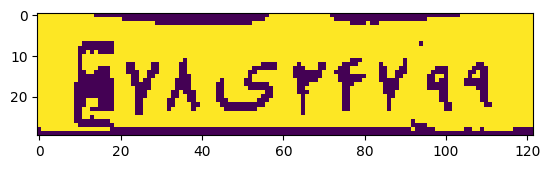

OCR Results for image0.jpg: [[[[6, 4], [116, 4], [116, 30], [6, 30]], '٩٩ ٢٤٧ى ٤٧٨', 0.5996363663812566]]


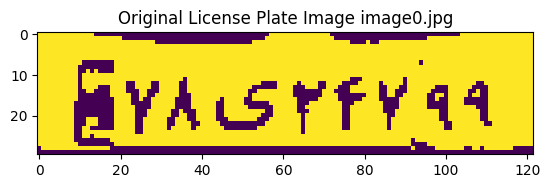

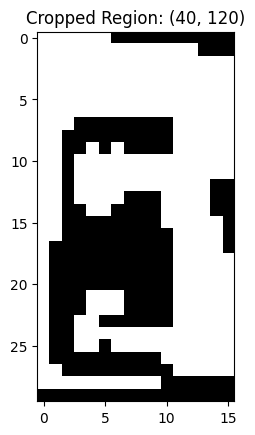

OCR Results for Cropped Region (40, 120): [[[[0, 3], [16, 3], [16, 29], [0, 29]], '٥', 0.23004881861430704]]


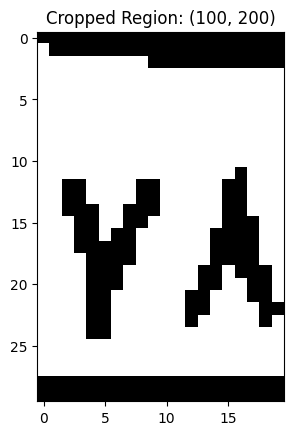

OCR Results for Cropped Region (100, 200): [[[[0, 6], [20, 6], [20, 30], [0, 30]], '٧٨', 0.9284376366513206]]


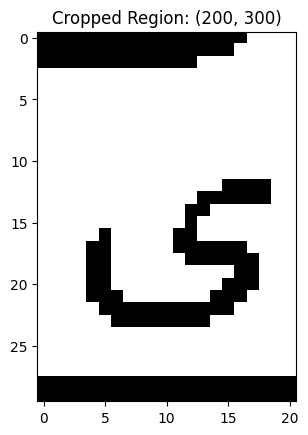

OCR Results for Cropped Region (200, 300): []


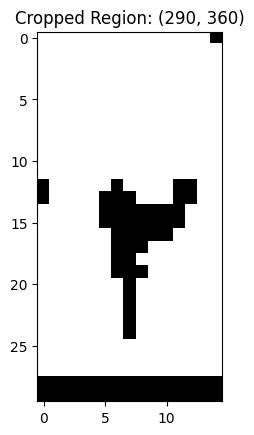

OCR Results for Cropped Region (290, 360): []


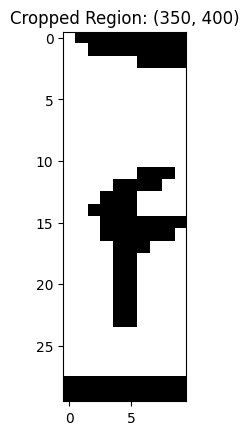

OCR Results for Cropped Region (350, 400): []


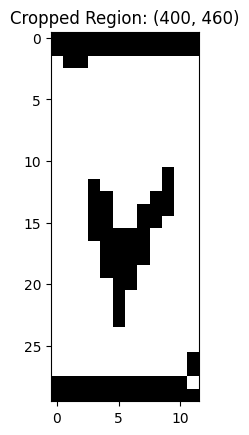

OCR Results for Cropped Region (400, 460): []


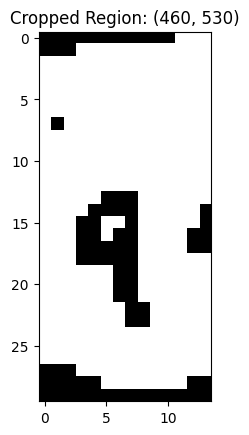

OCR Results for Cropped Region (460, 530): [[[[0, 3], [14, 3], [14, 29], [0, 29]], '٩', 0.94642557331861]]


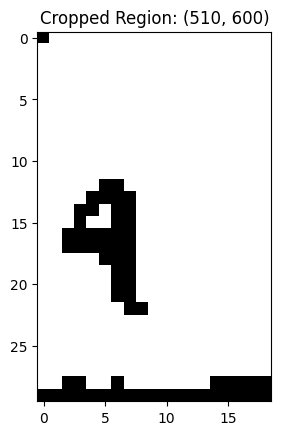

OCR Results for Cropped Region (510, 600): []


In [ ]:
# Remove the existing directory
folder_path = './predict_images'
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

# folder_path_results = './predict_Chracters'
# if os.path.exists(folder_path_results):
#     shutil.rmtree(folder_path_results)

# Initialize EasyOCR reader
reader = easyocr.Reader(['fa'], gpu=False)

# Load YOLO model for license plate detection
license_plate_detector = YOLO('./best.pt')
license_plate_Character_detector= YOLO('./chracterRecognitionBest.pt')
save_directory = './predict_images/crops/IR_License_Plate'
save_directory_Character='./predict_Characters'

# Load your image here
image = cv2.imread('./pelakir_1.jpg')

# Perform license plate detection

# Perform license plate detection
# results1 = license_plate_detector.predict(image, save_crop=True, project=".", name="Results1_predict_images", save_conf=True)
# results1_image_path = cv2.imread('/content/Results1_predict_images/crops/IR_License_Plate/image0.jpg')
# results1_img = ChnageAngWithOutPreProcessing(results1_image_path)
#تلاش شد تا با دوبار پردیکت کردن قسمت پلاک را کوچکتر کنیم و برای ان کتابخانه ها هم متمایز نوشته شد

results = license_plate_detector.predict(image, save_crop=True, project=".", name="predict_images", save_conf=True)
# Character_result= license_plate_Character_detector.predict(source='/content/predict_images/crops/IR_License_Plate/image0.jpg', save_crop=True, project=".", name="predict_Chracters", save_conf=True)

# Loop through the saved images and perform OCR
for filename in os.listdir(save_directory):
    filepath = os.path.join(save_directory, filename)
    result = cv2.imread(filepath)

    # Perform OCR on the license plate image
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
    gray_change = ChangeAng(gray)
    _, thresh = cv2.threshold(gray_change, 84, 255, cv2.THRESH_BINARY)

    # Pass the thresholded image to ChangeAng
    Detection_Image = ChangeAng(thresh)

    # Display the processed image
    plt.imshow(Detection_Image)
    plt.show()

    # Display the processed image after using yolo again
    # plt.imshow(results2)
    # plt.show()


    # # Perform OCR on the processed image
    detections = reader.readtext(Detection_Image)
    print(f"OCR Results for {filename}: {detections}")

    # # Display the original thresholded image
    plt.imshow(thresh)
    plt.title(f"Original License Plate Image {filename}")
    plt.show()










    #   # Use pytesseract to perform OCR on the processed image
    custom_config = r'--oem 3 --psm 6'  # Tesseract configuration options
    text = pytesseract.image_to_string(Detection_Image, config='--oem 3 --psm 6')



    #  # Display the detected license plate number
    # print("Detected License Plate Number:", text.strip())

   # for text, _, confidence in detections:
    #     if confidence >= 0.4:
    #         print(f"OCR Result for {filename}: {text} (Confidence: {confidence})")


#Cropping the part of license for detecting by easyocr
    h, w = Detection_Image.shape

      # Specify the chop factors
    chopfactors = [(40, 120), (100, 200), (200, 300), (290, 360), (350, 400), (400, 460), (460, 530), (510, 600)]

    # Loop through the saved images and perform OCR on cropped regions
    for factor in chopfactors:
        w1 = int((factor[0] / 600) * w)
        w2 = int((factor[1] / 600) * w)

        # Crop the Detection_Image based on the specified factors
        cropped_region = Detection_Image[:, w1:w2]


        # Perform OCR on the cropped region using EasyOCR
        detections_crop = reader.readtext(cropped_region)

        # Display the cropped region
        plt.imshow(cropped_region, cmap='gray')  # Assuming the image is grayscale
        plt.title(f"Cropped Region: {factor}")
        plt.show()

        # Display OCR results for the cropped region
        print(f"OCR Results for Cropped Region {factor}: {detections_crop}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

class_names = subdirs = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'ch', 'd', 'ein', 'f', 'g', 'ghaf', 'ghein', 'h2', 'hj', 'j', 'k', 'kh', 'l', 'm', 'n', 'p', 'r', 's', 'sad', 'sh', 't', 'ta', 'th', 'v', 'y', 'z', 'za', 'zad', 'zal', 'zh']
labels_nums = [i for i in range(0,len(class_names))]

h, w = Detection_Image.shape
chopfactors = [(40,120),(100,200),(180,280),(270,360),(350,400),(400,460),(460,530),(520,600)]




(8, 28, 28)

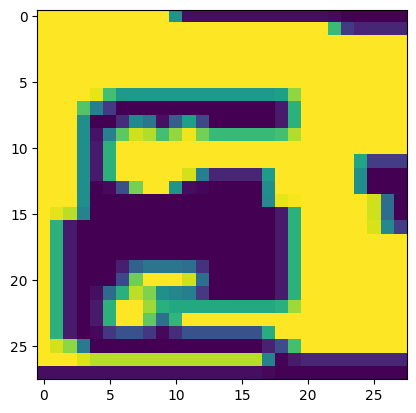

In [ ]:
plate_letters= []
for factor in chopfactors:
    w1 = int((factor[0]/600)*w)
    w2 = int((factor[1]/600)*w)
    letterpatch = Detection_Image[:,w1:w2]
    #cv.imwrite(f"{str(factor[0])}_{str(factor[1])}.png", letterpatch)
    letterpatch_resized = cv2.resize(letterpatch, (28,28), interpolation= cv2.INTER_LINEAR)
    plate_letters.append(letterpatch_resized)

plt.imshow(plate_letters[0])
plate_letters = np.array(plate_letters)
plate_letters.shape

In [ ]:
ocr_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/Plate_number_letter_Detection/simple_ocr_plates_model')


predictions = ocr_model.predict(plate_letters)


predictions

1/1 [==============================] - 1s 1s/step


array([[          0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           1,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,
                  0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0],
       [          0,           0,           0,           0,           0,           0,           1,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,           0,
                  0,           0,           0,           0,           0,           0,           0,           0,           0,      

In [ ]:
[class_names[k] for k in list(np.argmax(predictions, axis=1))]


['ch', '6', 'g', 'h2', '4', '7', 'ch', '1']

In [ ]:
[for k in list(np.argmax(predictions, axis=1))]


SyntaxError: ignored